# Final Project
## Ashley Mann

#### CMPINF2100  |  Introduction to Data-Centric Computing — August 2026

***

# Background & Context

The final project follows up on the EDA assignment with predictive modeling and evaluation. This analysis will allow you to measure associations with song popularity in the Spotify Songs dataset and build and evaluate models that can predict song popularity from song metadata.

### Jupyter Notebook Formatting

Like the EDA, this assignment will be completed with Jupyter Notebook on your own computer. It is graded by teaching staff.

Different from the EDA, however, you will create and submit multiple notebooks:

- A main notebook which includes answers to the lettered sections below (A, B, C, etc.). This main notebook should contain key code and visualizations, as well as important discussion and interpretation. Answers to all questions in the instructions must be included in this main notebook since that is the only notebook guaranteed to be examined by teaching staff for grading. Please name this main notebook final_project_main.ipynb. 

- Supporting notebooks that go in more detail for specific sections and can contain things that you tried but didn't end up being important for analysis, other unimportant figures and code, or anything else. Explanations and discussions are not required for supporting notebooks, which may or may not be reviewed by grading staff. Names of these notebooks should correspond to sections, such as model_fitting_supporting.ipynb, etc. If you refer to plots and findings from an EDA, you can submit an eda_supporting.ipynb notebook, as well. This can simply be a copy of your EDA assignment, but can also include any additions or revisions you did since you completed the EDA assignment.

## Dataset

For the final project, you will continue to use the Spotify Songs dataset that you explored in the EDA assignment. Here is  Here is a direct URL to the dataset CSV to read in to your notebook with Pandas: https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv   

## Final Project Goals

In the EDA, we aimed to understand how the values of variables can be used to predict the value of another variable. Now, we will use predictive modeling and evaluation to measure song popularity.

<span style="color:#E2725B">

- **Current Goal:** Predict a song's popularity based on the features associated with a song.

- **Previous Goal:** Understand the breadth of this dataset, keeping in mind values and features of the data that prepare us to consider prediction.

</span>

## Data Dictionary

| # | Variable | Class | Description |
|---|----------|-------|-------------|
| 1 | track_id | character | Song unique ID |
| 2 | track_name | character | Song Name |
| 3 | track_artist | character | Song Artist |
| 4 | track_popularity | double | Song Popularity (0-100) where higher is better |
| 5 | track_album_id | character | Album unique ID |
| 6 | track_album_name | character | Song album name |
| 7 | track_album_release_date | character | Date when album released |
| 8 | playlist_name | character | Name of playlist |
| 9 | playlist_id | character | Playlist ID |
| 10 | playlist_genre | character | Playlist genre |
| 11 | playlist_subgenre | character | Playlist subgenre |
| 12 | danceability | double | Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable. |
| 13 | energy | double | Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale. Perceptual features contributing to this attribute include dynamic range, perceived loudness, timbre, onset rate, and general entropy. |
| 14 | key | double | The estimated overall key of the track. Integers map to pitches using standard Pitch Class notation . E.g. 0 = C, 1 = C#/Db, 2 = D, and so on. If no key was detected, the value is -1. |
| 15 | loudness | double | The overall loudness of a track in decibels (dB). Loudness values are averaged across the entire track and are useful for comparing relative loudness of tracks. Loudness is the quality of a sound that is the primary psychological correlate of physical strength (amplitude). Values typical range between -60 and 0 db. |
| 16 | mode | double | Mode indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived. Major is represented by 1 and minor is 0. |
| 17 | speechiness | double | Speechiness detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks. |
| 18 | acousticness | double | A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic. |
| 19 | instrumentalness | double | Predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal". The closer the instrumentalness value is to 1.0, the greater the likelihood the track contains no vocal content. Values above 0.5 are intended to represent instrumental tracks, but confidence is higher as the value approaches 1.0. |
| 20 | liveness | double | Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live. |
| 21 | valence | double | A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry). |
| 22 | tempo | double | The overall estimated tempo of a track in beats per minute (BPM). In musical terminology, tempo is the speed or pace of a given piece and derives directly from the average beat duration. |
| 23 | duration_ms | double | Duration of song in milliseconds |

## Variable Categories (from EDA)

| ID Variables (7) | Continuous Variables (12) | Categorical Variables (3) | Outcome Variable (1) | Ignored Variables (1) |
|---|---|---|---|---|
| • track_id<br>• track_name<br>• track_album_id<br>• track_album_release_date<br>• track_album_name<br>• playlist_name<br>• playlist_id | • danceability<br>• energy<br>• key<br>• loudness<br>• mode<br>• speechiness<br>• acousticness<br>• instrumentalness<br>• liveness<br>• valence<br>• tempo<br>• duration_ms | • track_artist<br>• playlist_genre<br>• playlist_subgenre | • track_popularity_transformed | • track_popularity<br> |

## Final Project Outline

- **Part 1. Summary** 

- **Part 2: Model Fitting and Interpretation** 

- **Part 3: Model Predictions**

- **Part 4: Model Generalization Performance with Cross-validation** 

***

<span style="color:#17A697">

# Part 0: Imports & Data

</span>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from statsmodels.tools.eval_measures import rmse
# from patsy import dmatrices
# from sklearn.model_selection import KFold
# from sklearn.model_selection import cross_val_score
# from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv')
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [3]:
df.shape

(32833, 23)

In [4]:
df.dtypes

track_id                        str
track_name                      str
track_artist                    str
track_popularity              int64
track_album_id                  str
track_album_name                str
track_album_release_date        str
playlist_name                   str
playlist_id                     str
playlist_genre                  str
playlist_subgenre               str
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object

In [5]:
df.nunique()

track_id                    28356
track_name                  23449
track_artist                10692
track_popularity              101
track_album_id              22545
track_album_name            19743
track_album_release_date     4530
playlist_name                 449
playlist_id                   471
playlist_genre                  6
playlist_subgenre              24
danceability                  822
energy                        952
key                            12
loudness                    10222
mode                            2
speechiness                  1270
acousticness                 3731
instrumentalness             4729
liveness                     1624
valence                      1362
tempo                       17684
duration_ms                 19785
dtype: int64

In [6]:
df.isna().sum()

track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

In [7]:
df['track_popularity_shifted'] = np.where(df.track_popularity == 100, df.track_popularity - 0.1, df.track_popularity)
df['track_popularity_shifted'] = np.where(df.track_popularity == 0, df.track_popularity + 0.1, df.track_popularity_shifted)  
df['track_popularity_fraction'] = df.track_popularity_shifted/100
df['track_popularity_transformed'] = np.log(df.track_popularity_fraction / (1 - df.track_popularity_fraction))  

***

<span style="color:#17A697">

# Part 1: Summary

Complete this summary after finishing all the other parts.
1. Describe the major findings you have identified based on your analysis.

2. Which inputs/features seem to influence the response/outcome the most? What direction is their effect, i.e., as they increase or otherwise change value, what happens to the outcome variable?

3. Looking back at your EDA assignment, did the associations between variables found by predictive modeling align with what you found in the EDA? Indicate what evidence EDA and predictive modeling provided or did not provide for your conclusions.

4. What skills did you learn from going through this project? What skills, if any, can you take away from the project to apply to applications more specific to an area of interest for you?

</span>

<span style="color:#E2725B">

1. Lorem ipsum dolor sit amet, consectetur adipiscing.

2. Lorem ipsum dolor sit amet, consectetur adipiscing.

3. Lorem ipsum dolor sit amet, consectetur adipiscing.

4. Lorem ipsum dolor sit amet, consectetur adipiscing.

</span>


***

<span style="color:#17A697">

# Part 2: Model Fitting and Interpretation

In this section, you will consider multiple formulations (sets of features) for linear regression models and study the coefficients and their confidence intervals to interpret feature importance and quantify relationships to the transformed outcome variable. Before fitting models, if your EDA revealed that continuous variables have vastly different scales, standardize the variables before modeling. Feel free to make additional plots outside of what you completed for the EDA assignment if needed.

### Fit the following 6 models. You may fit additional models if you wish.

**Unlike the EDA assignment, please include all variables except ID variables and categorical variables with too many unique values,** unless the instructions note that you can use variables of your choice.

1. No INPUTS! Fit an INTERCEPT-ONLY or CONSTANT AVERAGE model.

2. Categorical inputs with additive features.

3. Continuous inputs with additive features.

4. All inputs (continuous and categorical) with additive features.

5. Inputs of your choice with linear main effects and pair-wise interactions. Select input variables that you think may be informative for prediction.

6. A nonlinear feature transformation on continuous variables of your choice. You can include any other non-transformed input variables you like if you wish. You can include polynomial transformations and/or sine or log-transformed variables. It's best if these transformations are informed by patterns you see in visualizations, but it's not required. You may include interaction variables if you wish.

### For each model that you fit you must answer the following questions associated with the regression coefficients:

1. How many coefficients were estimated?

2. WHICH coefficients (and thus features) are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

3. Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?

4. Calculate the r-squared and RMSE of the model on the entire dataset, which you used for training the model (later you will use cross-validation to protect against overfitting).

5. Plot a predicted vs observed figure.

### Best model interpretation
Answer the following questions to summarize your model fitting exploration:

1. Which model has the best performance on the training set? Describe which features the model used, don't just give a number to refer to the model.

2. Is the best model according to R-squared the SAME as the best model according to RMSE? 

3. Is the best model better than the INTERCEPT-ONLY model? How many coefficients are associated with the BEST model?

</span>

<span style="color:#17A697">

## Part 2A: Model Fitting

</span>

In [8]:
cont_var_df = df[['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']]
cont_var_df.head(10)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052
5,0.675,0.919,8,-5.385,1,0.1270,0.0799,0.000000,0.1430,0.585,124.982,163049
6,0.449,0.856,5,-4.788,0,0.0623,0.1870,0.000000,0.1760,0.152,112.648,187675
7,0.542,0.903,4,-2.419,0,0.0434,0.0335,0.000005,0.1110,0.367,127.936,207619
8,0.594,0.935,8,-3.562,1,0.0565,0.0249,0.000004,0.6370,0.366,127.015,193187
9,0.642,0.818,2,-4.552,1,0.0320,0.0567,0.000000,0.0919,0.590,124.957,253040


<span style="color:#E2725B">

Focusing on only continuous variables to prepare for standardization—the ones that haven't been logit transformed like the outcome variable.

</span>

In [9]:
cont_var_df_corr = cont_var_df.corr()
cont_var_df_corr

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
danceability,1.000000,-0.086073,0.011736,0.025335,-0.058647,0.181721,-0.024519,-0.008655,-0.123859,0.330523,-0.184084,-0.096879
energy,-0.086073,1.000000,0.010052,0.676625,-0.004800,-0.032150,-0.539745,0.033247,0.161223,0.151103,0.149951,0.012611
key,0.011736,0.010052,1.000000,0.000959,-0.174093,0.022607,0.004306,0.005968,0.002887,0.019914,-0.013370,0.015139
loudness,0.025335,0.676625,0.000959,1.000000,-0.019289,0.010339,-0.361638,-0.147824,0.077613,0.053384,0.093767,-0.115058
mode,-0.058647,-0.004800,-0.174093,-0.019289,1.000000,-0.063512,0.009415,-0.006741,-0.005549,0.002614,0.014329,0.015634
speechiness,0.181721,-0.032150,0.022607,0.010339,-0.063512,1.000000,0.026092,-0.103424,0.055426,0.064659,0.044603,-0.089431
acousticness,-0.024519,-0.539745,0.004306,-0.361638,0.009415,0.026092,1.000000,-0.006850,-0.077243,-0.016845,-0.112724,-0.081581
instrumentalness,-0.008655,0.033247,0.005968,-0.147824,-0.006741,-0.103424,-0.006850,1.000000,-0.005507,-0.175402,0.023335,0.063235
liveness,-0.123859,0.161223,0.002887,0.077613,-0.005549,0.055426,-0.077243,-0.005507,1.000000,-0.020560,0.021018,0.006138
valence,0.330523,0.151103,0.019914,0.053384,0.002614,0.064659,-0.016845,-0.175402,-0.020560,1.000000,-0.025732,-0.032225


<span style="color:#E2725B">

Coefficients.

</span>

In [10]:
scaler = StandardScaler()

In [11]:
scaler.fit(cont_var_df)

StandardScaler()

In [12]:
print(scaler.mean_)
print(scaler.scale_)

[ 6.54849520e-01  6.98619271e-01  5.37447081e+00 -6.71949913e+00
  5.65711327e-01  1.07068069e-01  1.75333715e-01  8.47471613e-02
  1.90176195e-01  5.10560974e-01  1.20881132e+02  2.25799812e+05]
[1.45083111e-01 1.80907279e-01 3.61160241e+00 2.98839088e+00
 4.95663214e-01 1.01312589e-01 2.19629196e-01 2.24226709e-01
 1.54314929e-01 2.33142424e-01 2.69032145e+01 5.98330950e+04]


<span style="color:#E2725B">

Using StandardScaler to show the mean and scale.

</span>

In [13]:
cont_var_df_std_arr = scaler.transform(cont_var_df)
cont_var_df_std_arr.shape

(32833, 12)

<span style="color:#E2725B">

Transforming the data.

</span>

In [14]:
cont_var_df_std = pd.DataFrame(cont_var_df_std_arr, columns = cont_var_df.columns)
cont_var_df_std.head(10)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.642049,1.201614,0.173200,1.367123,0.876177,-0.481362,-0.333898,-0.377953,-0.809230,0.031908,0.042927,-0.518874
1,0.490412,0.643317,1.557627,0.585766,0.876177,-0.688642,-0.468670,-0.359177,1.081061,0.782522,-0.777198,-1.056268
2,0.138889,1.284529,-1.211227,1.100090,-1.141322,-0.324422,-0.436799,-0.377849,-0.519562,0.439384,0.116227,-0.822017
3,0.435271,1.279002,0.450085,0.984309,0.876177,-0.050024,-0.667642,-0.377911,0.089582,-1.001795,0.039953,-0.947750
4,-0.033426,0.742815,-1.211227,0.685151,0.876177,-0.702460,-0.432701,-0.377953,-0.692585,0.919777,0.115037,-0.614172
5,0.138889,1.218197,0.726971,0.446561,0.876177,0.196737,-0.434522,-0.377953,-0.305714,0.319286,0.152430,-1.048764
6,-1.418839,0.869952,-0.103686,0.646334,-1.141322,-0.441881,0.053118,-0.377953,-0.091865,-1.537948,-0.306028,-0.637186
7,-0.777827,1.129754,-0.380571,1.439068,-1.141322,-0.628432,-0.645787,-0.377931,-0.513082,-0.615765,0.262231,-0.303859
8,-0.419411,1.306640,0.726971,1.056588,0.876177,-0.499129,-0.684944,-0.377935,2.895532,-0.620054,0.227998,-0.545063
9,-0.088567,0.659900,-0.934342,0.725306,0.876177,-0.740955,-0.540155,-0.377953,-0.636855,0.340732,0.151501,0.455270


<span style="color:#E2725B">

Final standardized values for the key continuous variables only.

</span>

In [15]:
cont_var_df_std.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04,3.283300e+04
mean,1.662038e-16,-2.458431e-16,-1.229215e-16,-2.908566e-16,-6.232641e-17,6.925157e-18,-7.963930e-17,-5.540125e-17,1.211902e-16,1.592786e-16,1.038774e-17,1.800541e-16
std,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00
min,-4.513616e+00,-3.860786e+00,-1.488113e+00,-1.329428e+01,-1.141322e+00,-1.056809e+00,-7.983170e-01,-3.779530e-01,-1.232390e+00,-2.189910e+00,-4.493185e+00,-3.706975e+00
25%,-6.330821e-01,-6.501633e-01,-9.343417e-01,-4.857132e-01,-1.141322e+00,-6.521210e-01,-7.295647e-01,-3.779530e-01,-6.316705e-01,-7.701772e-01,-7.776443e-01,-6.347793e-01
50%,1.182114e-01,1.237138e-01,1.731999e-01,1.852164e-01,8.761769e-01,-4.399065e-01,-4.322454e-01,-3.778812e-01,-4.093978e-01,6.172306e-03,4.099393e-02,-1.637858e-01
75%,7.316529e-01,7.815093e-01,1.003856e+00,6.941860e-01,8.761769e-01,2.460892e-01,3.627309e-01,-3.564123e-01,3.747130e-01,7.825218e-01,4.845840e-01,4.643783e-01
max,2.261810e+00,1.665940e+00,1.557627e+00,2.675185e+00,8.761769e-01,8.004256e+00,3.727493e+00,4.055060e+00,5.221943e+00,2.060710e+00,4.406866e+00,4.880413e+00


<span style="color:#E2725B">

Summary statistics.

</span>

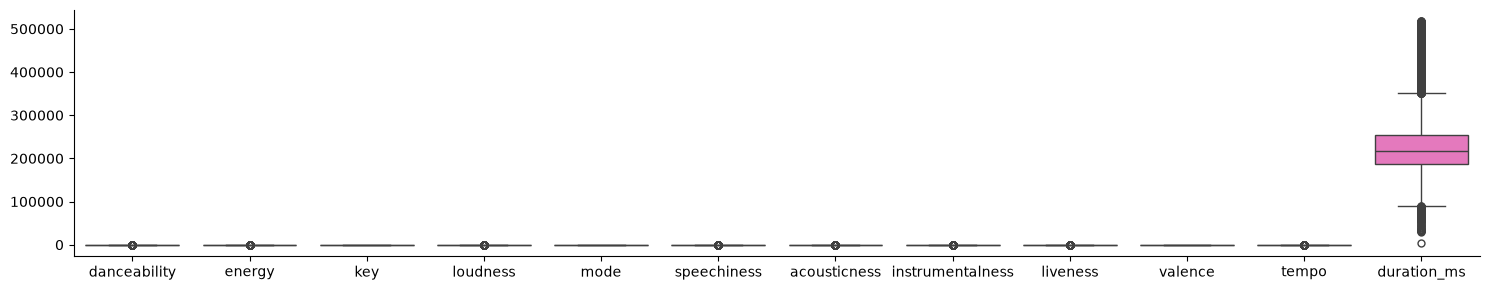

In [16]:
sns.catplot(data = cont_var_df, kind = 'box', height = 3, aspect = 5)
plt.show()

<span style="color:#E2725B">

Boxplots before scaling.

</span>

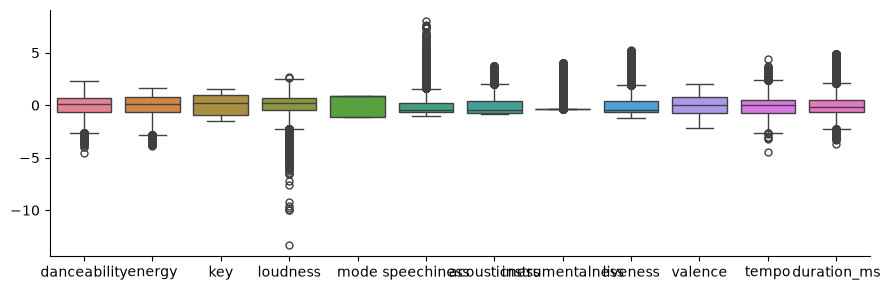

In [17]:
sns.catplot(data = cont_var_df_std, kind = 'box', height = 3, aspect = 3)
plt.show()

<span style="color:#E2725B">

Boxplots after scaling.

</span>

In [18]:
std_cont_df = pd.concat([cont_var_df_std, df[['playlist_genre', 'playlist_subgenre', 'track_popularity_transformed']]], axis = 1)
std_cont_df.head(10)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,playlist_genre,playlist_subgenre,track_popularity_transformed
0,0.642049,1.201614,0.173200,1.367123,0.876177,-0.481362,-0.333898,-0.377953,-0.809230,0.031908,0.042927,-0.518874,pop,dance pop,0.663294
1,0.490412,0.643317,1.557627,0.585766,0.876177,-0.688642,-0.468670,-0.359177,1.081061,0.782522,-0.777198,-1.056268,pop,dance pop,0.708185
2,0.138889,1.284529,-1.211227,1.100090,-1.141322,-0.324422,-0.436799,-0.377849,-0.519562,0.439384,0.116227,-0.822017,pop,dance pop,0.847298
3,0.435271,1.279002,0.450085,0.984309,0.876177,-0.050024,-0.667642,-0.377911,0.089582,-1.001795,0.039953,-0.947750,pop,dance pop,0.405465
4,-0.033426,0.742815,-1.211227,0.685151,0.876177,-0.702460,-0.432701,-0.377953,-0.692585,0.919777,0.115037,-0.614172,pop,dance pop,0.800119
5,0.138889,1.218197,0.726971,0.446561,0.876177,0.196737,-0.434522,-0.377953,-0.305714,0.319286,0.152430,-1.048764,pop,dance pop,0.708185
6,-1.418839,0.869952,-0.103686,0.646334,-1.141322,-0.441881,0.053118,-0.377953,-0.091865,-1.537948,-0.306028,-0.637186,pop,dance pop,0.489548
7,-0.777827,1.129754,-0.380571,1.439068,-1.141322,-0.628432,-0.645787,-0.377931,-0.513082,-0.615765,0.262231,-0.303859,pop,dance pop,0.800119
8,-0.419411,1.306640,0.726971,1.056588,0.876177,-0.499129,-0.684944,-0.377935,2.895532,-0.620054,0.227998,-0.545063,pop,dance pop,0.753772
9,-0.088567,0.659900,-0.934342,0.725306,0.876177,-0.740955,-0.540155,-0.377953,-0.636855,0.340732,0.151501,0.455270,pop,dance pop,0.708185


<span style="color:#E2725B">

Dataframe with the standardized continuous variables and the outcome variable. We've omitted the ID variables and the categorical variables with too many unique values.

ID variables:
- track_id
- track_name
- track_album_id
- track_album_name
- track_album_release_date
- playlist_name
- playlist_id

Variables with too many unique values:
- track artist

</span>

In [19]:
model_2a1 = smf.ols('track_popularity_transformed ~ 1', data = std_cont_df).fit()
model_2a1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     track_popularity_transformed   R-squared:                      -0.000
Model:                                      OLS   Adj. R-squared:                 -0.000
Method:                           Least Squares   F-statistic:                       nan
Date:                          Sat, 08 Aug 2026   Prob (F-statistic):                nan
Time:                                  16:13:59   Log-Likelihood:                -72659.
No. Observations:                         32833   AIC:                         1.453e+05
Df Residuals:                             32832   BIC:                         1.453e+05
Df Model:                                     0                                         
Covariance Type:                      nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8274      0.012    -67.767      0.000      -0.851      -0.803
==============================================================================
Omnibus:                     9407.113   Durbin-Watson:                   1.123
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            21438.783
Skew:                          -1.657   Prob(JB):                         0.00
Kurtosis:                       5.164   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<span style="color:#E2725B">

**Model 2A.1** — Intercept-only model.

</span>

In [20]:
model_2a2 = smf.ols(formula = 'track_popularity_transformed ~ playlist_genre + playlist_subgenre', data = std_cont_df).fit()
model_2a2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     track_popularity_transformed   R-squared:                       0.087
Model:                                      OLS   Adj. R-squared:                  0.086
Method:                           Least Squares   F-statistic:                     115.7
Date:                          Sat, 08 Aug 2026   Prob (F-statistic):               0.00
Time:                                  16:13:59   Log-Likelihood:                -71166.
No. Observations:                         32833   AIC:                         1.424e+05
Df Residuals:                             32805   BIC:                         1.426e+05
Df Model:                                    27                                         
Covariance Type:                      nonrobust                                         
==================================================================================================================
                                                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                                      -3.416e+11   8.87e+11     -0.385      0.700   -2.08e+12     1.4e+12
playlist_genre[T.latin]                        -1.122e+11   2.94e+11     -0.382      0.702   -6.88e+11    4.63e+11
playlist_genre[T.pop]                           -2.59e+10   1.08e+12     -0.024      0.981   -2.14e+12    2.08e+12
playlist_genre[T.r&b]                           8.361e+10   6.51e+11      0.128      0.898   -1.19e+12    1.36e+12
playlist_genre[T.rap]                           2.128e+11   6.09e+11      0.350      0.727    -9.8e+11    1.41e+12
playlist_genre[T.rock]                          3.416e+11   8.87e+11      0.385      0.700    -1.4e+12    2.08e+12
playlist_subgenre[T.big room]                   3.416e+11   8.87e+11      0.385      0.700    -1.4e+12    2.08e+12
playlist_subgenre[T.classic rock]                  0.2441      0.087      2.790      0.005       0.073       0.416
playlist_subgenre[T.dance pop]                  3.675e+11   7.38e+11      0.498      0.619   -1.08e+12    1.81e+12
playlist_subgenre[T.electro house]              3.416e+11   8.87e+11      0.385      0.700    -1.4e+12    2.08e+12
playlist_subgenre[T.electropop]                 3.675e+11   7.38e+11      0.498      0.619   -1.08e+12    1.81e+12
playlist_subgenre[T.gangster rap]               1.288e+11   1.01e+12      0.127      0.899   -1.86e+12    2.11e+12
playlist_subgenre[T.hard rock]                    -0.1090      0.085     -1.284      0.199      -0.275       0.057
playlist_subgenre[T.hip hop]                    1.288e+11   1.01e+12      0.127      0.899   -1.86e+12    2.11e+12
playlist_subgenre[T.hip pop]                     2.58e+11   9.92e+11      0.260      0.795   -1.69e+12     2.2e+12
playlist_subgenre[T.indie poptimism]            3.675e+11   7.38e+11      0.498      0.619   -1.08e+12    1.81e+12
playlist_subgenre[T.latin hip hop]              4.538e+11   1.03e+12      0.443      0.658   -1.56e+12    2.46e+12
playlist_subgenre[T.latin pop]                  4.538e+11   1.03e+12      0.443      0.658   -1.56e+12    2.46e+12
playlist_subgenre[T.neo soul]                    2.58e+11   9.92e+11      0.260      0.795   -1.69e+12     2.2e+12
playlist_subgenre[T.new jack swing]              2.58e+11   9.92e+11      0.260      0.795   -1.69e+12     2.2e+12
playlist_subgenre[T.permanent wave]                1.2398      0.091     13.652      0.000       1.062       1.418
playlist_subgenre[T.pop edm]                    3.416e+11   8.87e+11      0.385      0.700    -1.4e+12    2.08e+12
playlist_subgenre[T.post-teen pop]              3.675e+11   7.38e+11      0.498      0.619   -1.08

<span style="color:#E2725B">

**Model 2A.2** — Categorical inputs with additive features.

</span>

In [21]:
model_2a3 = smf.ols(formula = 'track_popularity_transformed ~ danceability + energy + key + loudness + mode + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms', data = std_cont_df).fit()
model_2a3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     track_popularity_transformed   R-squared:                       0.057
Model:                                      OLS   Adj. R-squared:                  0.056
Method:                           Least Squares   F-statistic:                     164.0
Date:                          Sat, 08 Aug 2026   Prob (F-statistic):               0.00
Time:                                  16:13:59   Log-Likelihood:                -71703.
No. Observations:                         32833   AIC:                         1.434e+05
Df Residuals:                             32820   BIC:                         1.435e+05
Df Model:                                    12                                         
Covariance Type:                      nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.8274      0.012    -69.756      0.000      -0.851      -0.804
danceability         0.0656      0.014      4.828      0.000       0.039       0.092
energy              -0.3788      0.019    -19.574      0.000      -0.417      -0.341
key                 -0.0052      0.012     -0.431      0.666      -0.029       0.018
loudness             0.2821      0.017     16.480      0.000       0.249       0.316
mode                 0.0224      0.012      1.857      0.063      -0.001       0.046
speechiness         -0.0679      0.012     -5.535      0.000      -0.092      -0.044
acousticness         0.0671      0.014      4.673      0.000       0.039       0.095
instrumentalness    -0.1893      0.013    -14.997      0.000      -0.214      -0.165
liveness            -0.0646      0.012     -5.318      0.000      -0.088      -0.041
valence              0.0136      0.013      1.019      0.308      -0.013       0.040
tempo                0.0436      0.012      3.558      0.000       0.020       0.068
duration_ms         -0.2762      0.012    -22.704      0.000      -0.300      -0.252
==============================================================================
Omnibus:                     9269.170   Durbin-Watson:                   1.223
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            21010.972
Skew:                          -1.633   Prob(JB):                         0.00
Kurtosis:                       5.165   Cond. No.                         3.10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<span style="color:#E2725B">

**Model 2A.3** — Continuous inputs with additive features.

</span>

In [22]:
model_2a4 = smf.ols(formula = 'track_popularity_transformed ~ playlist_genre + playlist_subgenre + danceability + energy + key + loudness + mode + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms', data = std_cont_df).fit()
model_2a4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     track_popularity_transformed   R-squared:                       0.116
Model:                                      OLS   Adj. R-squared:                  0.115
Method:                           Least Squares   F-statistic:                     119.7
Date:                          Sat, 08 Aug 2026   Prob (F-statistic):               0.00
Time:                                  16:14:00   Log-Likelihood:                -70632.
No. Observations:                         32833   AIC:                         1.413e+05
Df Residuals:                             32796   BIC:                         1.416e+05
Df Model:                                    36                                         
Covariance Type:                      nonrobust                                         
==================================================================================================================
                                                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                                       2.232e+11   8.81e+11      0.253      0.800    -1.5e+12    1.95e+12
playlist_genre[T.latin]                        -7.328e+10   2.48e+11     -0.296      0.767   -5.59e+11    4.12e+11
playlist_genre[T.pop]                          -4.627e+11    1.8e+12     -0.256      0.798      -4e+12    3.07e+12
playlist_genre[T.r&b]                           1.129e+11   6.04e+11      0.187      0.852   -1.07e+12     1.3e+12
playlist_genre[T.rap]                          -1.729e+11    5.8e+11     -0.298      0.766   -1.31e+12    9.64e+11
playlist_genre[T.rock]                         -2.232e+11   8.81e+11     -0.253      0.800   -1.95e+12     1.5e+12
playlist_subgenre[T.big room]                  -2.232e+11   8.81e+11     -0.253      0.800   -1.95e+12     1.5e+12
playlist_subgenre[T.classic rock]                  0.2355      0.086      2.728      0.006       0.066       0.405
playlist_subgenre[T.dance pop]                  2.395e+11   1.69e+12      0.142      0.887   -3.07e+12    3.54e+12
playlist_subgenre[T.electro house]             -2.232e+11   8.81e+11     -0.253      0.800   -1.95e+12     1.5e+12
playlist_subgenre[T.electropop]                 2.395e+11   1.69e+12      0.142      0.887   -3.07e+12    3.54e+12
playlist_subgenre[T.gangster rap]              -5.035e+10    9.9e+11     -0.051      0.959   -1.99e+12    1.89e+12
playlist_subgenre[T.hard rock]                    -0.0793      0.085     -0.934      0.350      -0.246       0.087
playlist_subgenre[T.hip hop]                   -5.035e+10    9.9e+11     -0.051      0.959   -1.99e+12    1.89e+12
playlist_subgenre[T.hip pop]                   -3.362e+11   9.96e+11     -0.337      0.736   -2.29e+12    1.62e+12
playlist_subgenre[T.indie poptimism]            2.395e+11   1.69e+12      0.142      0.887   -3.07e+12    3.54e+12
playlist_subgenre[T.latin hip hop]             -1.499e+11    9.1e+11     -0.165      0.869   -1.93e+12    1.63e+12
playlist_subgenre[T.latin pop]                 -1.499e+11    9.1e+11     -0.165      0.869   -1.93e+12    1.63e+12
playlist_subgenre[T.neo soul]                  -3.362e+11   9.96e+11     -0.337      0.736   -2.29e+12    1.62e+12
playlist_subgenre[T.new jack swing]            -3.362e+11   9.96e+11     -0.337      0.736   -2.29e+12    1.62e+12
playlist_subgenre[T.permanent wave]                1.1892      0.090     13.263      0.000       1.013       1.365
playlist_subgenre[T.pop edm]                   -2.232e+11   8.81e+11     -0.253      0.800   -1.95e+12     1.5e+12
playlist_subgenre[T.post-teen pop]              2.395e+11   1.69e+12      0.142      0.887   -3.07

<span style="color:#E2725B">

**Model 2A.4** — All inputs (continuous and categorical) with additive features.

</span>

In [23]:
model_2a5 = smf.ols(formula = 'track_popularity_transformed ~ danceability * energy + danceability * valence + danceability * tempo + energy * valence + energy * tempo + valence * tempo', data = std_cont_df).fit()
model_2a5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     track_popularity_transformed   R-squared:                       0.016
Model:                                      OLS   Adj. R-squared:                  0.016
Method:                           Least Squares   F-statistic:                     54.72
Date:                          Sat, 08 Aug 2026   Prob (F-statistic):          3.21e-110
Time:                                  16:14:00   Log-Likelihood:                -72387.
No. Observations:                         32833   AIC:                         1.448e+05
Df Residuals:                             32822   BIC:                         1.449e+05
Df Model:                                    10                                         
Covariance Type:                      nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.8569      0.013    -63.850      0.000      -0.883      -0.831
danceability             0.1040      0.014      7.627      0.000       0.077       0.131
energy                  -0.2272      0.013    -17.340      0.000      -0.253      -0.202
danceability:energy     -0.0739      0.013     -5.795      0.000      -0.099      -0.049
valence                  0.0260      0.013      1.965      0.049     6.7e-05       0.052
danceability:valence     0.0429      0.013      3.288      0.001       0.017       0.069
tempo                    0.0385      0.014      2.797      0.005       0.012       0.066
danceability:tempo       0.0103      0.012      0.829      0.407      -0.014       0.035
energy:valence           0.0921      0.013      6.929      0.000       0.066       0.118
energy:tempo            -0.0175      0.013     -1.390      0.165      -0.042       0.007
valence:tempo            0.0172      0.014      1.190      0.234      -0.011       0.046
==============================================================================
Omnibus:                     9329.167   Durbin-Watson:                   1.146
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            21110.151
Skew:                          -1.648   Prob(JB):                         0.00
Kurtosis:                       5.138   Cond. No.                         2.23
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<span style="color:#E2725B">

**Model 2A.5** — Inputs of your choice with linear main effects and pair-wise interactions.

</span>

In [76]:
model_2a6_loudness = smf.ols('track_popularity_transformed ~ loudness + np.power(loudness, 2)', data = std_cont_df).fit()
model_2a6_loudness.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     track_popularity_transformed   R-squared:                       0.001
Model:                                      OLS   Adj. R-squared:                  0.001
Method:                           Least Squares   F-statistic:                     13.20
Date:                          Sat, 08 Aug 2026   Prob (F-statistic):           1.87e-06
Time:                                  18:52:29   Log-Likelihood:                -72645.
No. Observations:                         32833   AIC:                         1.453e+05
Df Residuals:                             32830   BIC:                         1.453e+05
Df Model:                                     2                                         
Covariance Type:                      nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.8222      0.013    -61.088      0.000      -0.849      -0.796
loudness                  0.0545      0.014      3.775      0.000       0.026       0.083
np.power(loudness, 2)    -0.0052      0.006     -0.923      0.356      -0.016       0.006
==============================================================================
Omnibus:                     9443.373   Durbin-Watson:                   1.125
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            21587.433
Skew:                          -1.662   Prob(JB):                         0.00
Kurtosis:                       5.174   Cond. No.                         3.67
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [73]:
model_2a6_tempo = smf.ols('track_popularity_transformed ~ tempo + np.power(tempo, 2)', data = std_cont_df).fit()
model_2a6_tempo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     track_popularity_transformed   R-squared:                       0.002
Model:                                      OLS   Adj. R-squared:                  0.002
Method:                           Least Squares   F-statistic:                     26.78
Date:                          Sat, 08 Aug 2026   Prob (F-statistic):           2.40e-12
Time:                                  18:42:40   Log-Likelihood:                -72632.
No. Observations:                         32833   AIC:                         1.453e+05
Df Residuals:                             32830   BIC:                         1.453e+05
Df Model:                                     2                                         
Covariance Type:                      nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.8930      0.015    -58.706      0.000      -0.923      -0.863
tempo                 -0.0494      0.013     -3.766      0.000      -0.075      -0.024
np.power(tempo, 2)     0.0656      0.009      7.218      0.000       0.048       0.083
==============================================================================
Omnibus:                     9400.191   Durbin-Watson:                   1.127
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            21413.241
Skew:                          -1.656   Prob(JB):                         0.00
Kurtosis:                       5.163   Cond. No.                         2.67
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<span style="color:#E2725B">

**Model 2A.6** — A nonlinear feature transformation on continuous variables of your choice.

</span>

<span style="color:#17A697">

## Part 2B: Questions Associated with each Model

</span>

<span style="color:#17A697">

### Model 2A.1 — Intercept-only model

</span>

<span style="color:#17A697">

Q1: How many coefficients were estimated?

</span>

In [36]:
len(model_2a1.params)

1

<span style="color:#E2725B">

1 coefficient.

</span>

<span style="color:#17A697">

Q2: WHICH coefficients (and thus features) are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

</span>

<span style="color:#E2725B">

These coefficients are statistically significant with a p value of < 0.05:

- Intercept
    - coef -0.8274 (negative) / p value 0.000

</span>

<span style="color:#17A697">

Q3: Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?

</span>

<span style="color:#E2725B">

Of the coefficients that are statistically signifant, these 2 have the highest magnitude coefficient values:

- Intercept
    - coef -0.8274 (negative) / p value 0.000

</span>

<span style="color:#17A697">

Q4: Calculate the r-squared and RMSE of the model on the entire dataset, which you used for training the model (later you will use cross-validation to protect against overfitting).

</span>

In [43]:
model_2a1_formula = 'track_popularity_transformed ~ 1'

model_2a1 = smf.ols(model_2a1_formula, data = std_cont_df).fit()
model_2a1_rsquared = model_2a1.rsquared
print('R squared:', model_2a1_rsquared)

model_2a1_preds = model_2a1.predict(std_cont_df)
model_2a1_rmse = rmse(std_cont_df['track_popularity_transformed'], model_2a1_preds)
print("RMSE:", model_2a1_rmse)

R squared: -2.220446049250313e-16
RMSE: 2.212308770791808


<span style="color:#17A697">

Q5: Plot a predicted vs observed figure.

</span>

In [47]:
model_2a1_preds_df = pd.concat([std_cont_df, model_2a1_preds], axis = 1)
model_2a1_preds_df.rename(columns={0: 'predicted'}, inplace=True)
model_2a1_preds_df

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,playlist_genre,playlist_subgenre,track_popularity_transformed,predicted
0,0.642049,1.201614,0.173200,1.367123,0.876177,-0.481362,-0.333898,-0.377953,-0.809230,0.031908,0.042927,-0.518874,pop,dance pop,0.663294,-0.827397
1,0.490412,0.643317,1.557627,0.585766,0.876177,-0.688642,-0.468670,-0.359177,1.081061,0.782522,-0.777198,-1.056268,pop,dance pop,0.708185,-0.827397
2,0.138889,1.284529,-1.211227,1.100090,-1.141322,-0.324422,-0.436799,-0.377849,-0.519562,0.439384,0.116227,-0.822017,pop,dance pop,0.847298,-0.827397
3,0.435271,1.279002,0.450085,0.984309,0.876177,-0.050024,-0.667642,-0.377911,0.089582,-1.001795,0.039953,-0.947750,pop,dance pop,0.405465,-0.827397
4,-0.033426,0.742815,-1.211227,0.685151,0.876177,-0.702460,-0.432701,-0.377953,-0.692585,0.919777,0.115037,-0.614172,pop,dance pop,0.800119,-0.827397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,-1.563583,1.234780,-0.934342,1.641519,0.876177,-0.132936,-0.449547,-0.377953,-0.799509,-1.289173,0.270929,-0.358076,edm,progressive electro house,-0.322773,-0.827397
32829,-0.915679,0.483014,-1.488113,0.755423,0.876177,-0.642251,-0.790531,-0.358910,1.197705,-0.474221,0.266134,2.127922,edm,progressive electro house,-1.386294,-0.827397
32830,-0.867431,0.676483,0.173200,0.609190,-1.141322,-0.582041,-0.306579,-0.377948,-0.260352,-0.319809,0.264201,-0.262193,edm,progressive electro house,-1.815290,-0.827397
32831,-0.198848,1.046839,-0.934342,1.123849,0.876177,0.019069,-0.762256,0.188438,0.990337,-0.868829,0.264908,2.367121,edm,progressive electro house,-1.734601,-0.827397


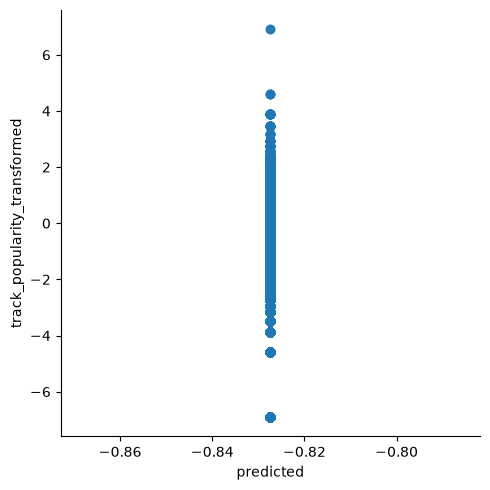

In [86]:
sns.lmplot(data = model_2a1_preds_df, x = 'predicted', y = 'track_popularity_transformed')
plt.show()

<span style="color:#17A697">

### Model 2A.2 — Categorical inputs with additive features

</span>

<span style="color:#17A697">

Q1: How many coefficients were estimated?

</span>

In [35]:
len(model_2a2.params)

29

<span style="color:#E2725B">

29 coefficients.

</span>

<span style="color:#17A697">

Q2: WHICH coefficients (and thus features) are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

</span>

<span style="color:#E2725B">

These coefficients are statistically significant with a p value of < 0.05:

- playlist_subgenre[T.classic rock]
    - coef 0.2441 (positive) / p value 0.005
- playlist_subgenre[T.permanent wave]
    - coef 1.2398 (positive) / p value 0.000
    
</span>

<span style="color:#17A697">

Q3: Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?

</span>

<span style="color:#E2725B">

Of the coefficients that are statistically signifant, these 2 have the highest magnitude coefficient values:

- playlist_subgenre[T.classic rock]
    - coef 0.2441 (positive) / p value 0.005
- playlist_subgenre[T.permanent wave]
    - coef 1.2398 (positive) / p value 0.000
    
</span>

<span style="color:#17A697">

Q4: Calculate the r-squared and RMSE of the model on the entire dataset, which you used for training the model (later you will use cross-validation to protect against overfitting).

</span>

In [42]:
model_2a2_formula = 'track_popularity_transformed ~ playlist_genre + playlist_subgenre'

model_2a2 = smf.ols(model_2a2_formula, data = std_cont_df).fit()
model_2a2_rsquared = model_2a2.rsquared
print('R squared:', model_2a2_rsquared)

model_2a2_preds = model_2a2.predict(std_cont_df)
model_2a2_rmse = rmse(std_cont_df['track_popularity_transformed'], model_2a2_preds)
print("RMSE:", model_2a2_rmse)

R squared: 0.08693381443090697
RMSE: 2.1139605132439026


<span style="color:#17A697">

Q5: Plot a predicted vs observed figure.

</span>

In [46]:
model_2a2_preds_df = pd.concat([std_cont_df, model_2a2_preds], axis = 1)
model_2a2_preds_df.rename(columns={0: 'predicted'}, inplace=True)
model_2a2_preds_df

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,playlist_genre,playlist_subgenre,track_popularity_transformed,predicted
0,0.642049,1.201614,0.173200,1.367123,0.876177,-0.481362,-0.333898,-0.377953,-0.809230,0.031908,0.042927,-0.518874,pop,dance pop,0.663294,-0.008057
1,0.490412,0.643317,1.557627,0.585766,0.876177,-0.688642,-0.468670,-0.359177,1.081061,0.782522,-0.777198,-1.056268,pop,dance pop,0.708185,-0.008057
2,0.138889,1.284529,-1.211227,1.100090,-1.141322,-0.324422,-0.436799,-0.377849,-0.519562,0.439384,0.116227,-0.822017,pop,dance pop,0.847298,-0.008057
3,0.435271,1.279002,0.450085,0.984309,0.876177,-0.050024,-0.667642,-0.377911,0.089582,-1.001795,0.039953,-0.947750,pop,dance pop,0.405465,-0.008057
4,-0.033426,0.742815,-1.211227,0.685151,0.876177,-0.702460,-0.432701,-0.377953,-0.692585,0.919777,0.115037,-0.614172,pop,dance pop,0.800119,-0.008057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,-1.563583,1.234780,-0.934342,1.641519,0.876177,-0.132936,-0.449547,-0.377953,-0.799509,-1.289173,0.270929,-0.358076,edm,progressive electro house,-0.322773,-2.138428
32829,-0.915679,0.483014,-1.488113,0.755423,0.876177,-0.642251,-0.790531,-0.358910,1.197705,-0.474221,0.266134,2.127922,edm,progressive electro house,-1.386294,-2.138428
32830,-0.867431,0.676483,0.173200,0.609190,-1.141322,-0.582041,-0.306579,-0.377948,-0.260352,-0.319809,0.264201,-0.262193,edm,progressive electro house,-1.815290,-2.138428
32831,-0.198848,1.046839,-0.934342,1.123849,0.876177,0.019069,-0.762256,0.188438,0.990337,-0.868829,0.264908,2.367121,edm,progressive electro house,-1.734601,-2.138428


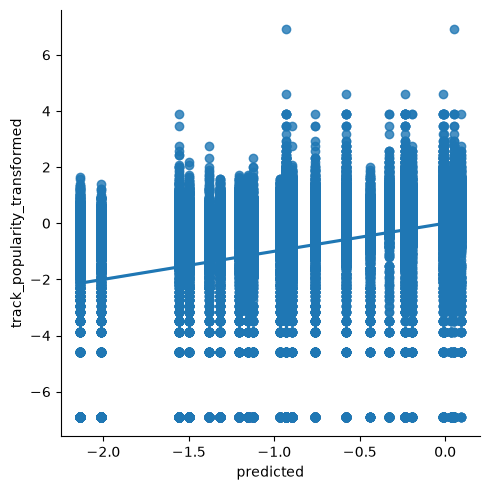

In [48]:
sns.lmplot(data = model_2a2_preds_df, x = 'predicted', y = 'track_popularity_transformed')
plt.show()

<span style="color:#17A697">

### Model 2A.3 — Continuous inputs with additive features

</span>

<span style="color:#17A697">

Q1: How many coefficients were estimated?

</span>

In [37]:
len(model_2a3.params)

13

<span style="color:#E2725B">

13 coefficients.

</span>

<span style="color:#17A697">

Q2: WHICH coefficients (and thus features) are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

</span>

<span style="color:#E2725B">

These coefficients are statistically significant with a p value of < 0.05:

- Intercept
    - coef -0.8274 (negative) / p value 0.000
- danceability
    - coef 0.0656 (positive) / p value 0.000
- energy
    - coef -0.3788 (negative) / p value 0.000
- loudness
    - coef 0.2821 (positive) / p value 0.000
- speechiness
    - coef -0.0679 (negative) / p value 0.000
- acousticness
    - coef 0.0671 (positive) / p value 0.000
- instrumentalness
    - coef -0.1893 (negative) / p value 0.000
- liveness
    - coef -0.0646 (negative) / p value 0.000
- tempo
    - coef 0.0436 (positive) / p value 0.000
- duration_ms
    - coef -0.2762 (negative) / p value 0.000


</span>

<span style="color:#17A697">

Q3: Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?

</span>

<span style="color:#E2725B">

Of the coefficients that are statistically signifant, these 2 have the highest magnitude coefficient values:

- Intercept
    - coef -0.8274 (negative) / p value 0.000
- energy
    - coef -0.3788 (negative) / p value 0.000
    
</span>

<span style="color:#17A697">

Q4: Calculate the r-squared and RMSE of the model on the entire dataset, which you used for training the model (later you will use cross-validation to protect against overfitting).

</span>

In [50]:
model_2a3_formula = 'track_popularity_transformed ~ danceability + energy + key + loudness + mode + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms'

model_2a3 = smf.ols(model_2a3_formula, data = std_cont_df).fit()
model_2a3_rsquared = model_2a3.rsquared
print('R squared:', model_2a3_rsquared)

model_2a3_preds = model_2a3.predict(std_cont_df)
model_2a3_rmse = rmse(std_cont_df['track_popularity_transformed'], model_2a3_preds)
print("RMSE:", model_2a3_rmse)

R squared: 0.056567045702857865
RMSE: 2.148826059587692


<span style="color:#17A697">

Q5: Plot a predicted vs observed figure.

</span>

In [51]:
model_2a3_preds_df = pd.concat([std_cont_df, model_2a3_preds], axis = 1)
model_2a3_preds_df.rename(columns={0: 'predicted'}, inplace=True)
model_2a3_preds_df

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,playlist_genre,playlist_subgenre,track_popularity_transformed,predicted
0,0.642049,1.201614,0.173200,1.367123,0.876177,-0.481362,-0.333898,-0.377953,-0.809230,0.031908,0.042927,-0.518874,pop,dance pop,0.663294,-0.556199
1,0.490412,0.643317,1.557627,0.585766,0.876177,-0.688642,-0.468670,-0.359177,1.081061,0.782522,-0.777198,-1.056268,pop,dance pop,0.708185,-0.580176
2,0.138889,1.284529,-1.211227,1.100090,-1.141322,-0.324422,-0.436799,-0.377849,-0.519562,0.439384,0.116227,-0.822017,pop,dance pop,0.847298,-0.677881
3,0.435271,1.279002,0.450085,0.984309,0.876177,-0.050024,-0.667642,-0.377911,0.089582,-1.001795,0.039953,-0.947750,pop,dance pop,0.405465,-0.714057
4,-0.033426,0.742815,-1.211227,0.685151,0.876177,-0.702460,-0.432701,-0.377953,-0.692585,0.919777,0.115037,-0.614172,pop,dance pop,0.800119,-0.569541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,-1.563583,1.234780,-0.934342,1.641519,0.876177,-0.132936,-0.449547,-0.377953,-0.799509,-1.289173,0.270929,-0.358076,edm,progressive electro house,-0.322773,-0.714714
32829,-0.915679,0.483014,-1.488113,0.755423,0.876177,-0.642251,-0.790531,-0.358910,1.197705,-0.474221,0.266134,2.127922,edm,progressive electro house,-1.386294,-1.431212
32830,-0.867431,0.676483,0.173200,0.609190,-1.141322,-0.582041,-0.306579,-0.377948,-0.260352,-0.319809,0.264201,-0.262193,edm,progressive electro house,-1.815290,-0.808242
32831,-0.198848,1.046839,-0.934342,1.123849,0.876177,0.019069,-0.762256,0.188438,0.990337,-0.868829,0.264908,2.367121,edm,progressive electro house,-1.734601,-1.701384


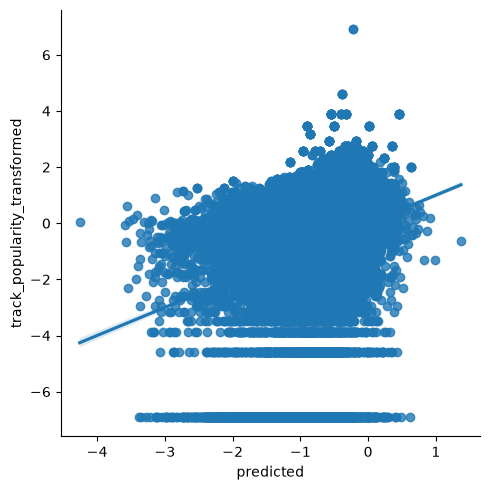

In [52]:
sns.lmplot(data = model_2a3_preds_df, x = 'predicted', y = 'track_popularity_transformed')
plt.show()

<span style="color:#17A697">

### Model 2A.4 — All inputs (continuous and categorical) with additive features

</span>

<span style="color:#17A697">

Q1: How many coefficients were estimated?

</span>

In [38]:
len(model_2a4.params)

41

<span style="color:#E2725B">

41 coefficients.

</span>

<span style="color:#17A697">

Q2: WHICH coefficients (and thus features) are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

</span>

<span style="color:#E2725B">

These coefficients are statistically significant with a p value of < 0.05:

- playlist_subgenre[T.classic rock]
    - coef 0.2355 (positive) / p value 0.006
- playlist_subgenre[T.permanent wave]	
    - coef 1.1892 (positive) / p value 0.000
- danceability
    - coef 0.1195 (negative/positive) / p value 0.000
- energy
    - coef -0.3259 (negative) / p value 0.000
- loudness
    - coef 0.2385 (positive) / p value 0.000
- instrumentalness
    - coef -0.1743 (negative) / p value 0.000
- liveness
    - coef -0.0418 (negative) / p value 0.000
- valence
    - coef -0.0432 (negative) / p value 0.002
- duration_ms
    - coef -0.1720 (negative) / p value 0.000

</span>

<span style="color:#17A697">

Q3: Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?

</span>

<span style="color:#E2725B">

Of the coefficients that are statistically signifant, these 2 have the highest magnitude coefficient values:

- playlist_subgenre[T.permanent wave]	
    - coef 1.1892 (positive) / p value 0.000
- energy
    - coef -0.3259 (negative) / p value 0.000

</span>

<span style="color:#17A697">

Q4: Calculate the r-squared and RMSE of the model on the entire dataset, which you used for training the model (later you will use cross-validation to protect against overfitting).

</span>

In [53]:
model_2a4_formula = 'track_popularity_transformed ~ playlist_genre + playlist_subgenre + danceability + energy + key + loudness + mode + speechiness + acousticness + instrumentalness + liveness + valence + tempo + duration_ms'

model_2a4 = smf.ols(model_2a4_formula, data = std_cont_df).fit()
model_2a4_rsquared = model_2a4.rsquared
print('R squared:', model_2a4_rsquared)

model_2a4_preds = model_2a4.predict(std_cont_df)
model_2a4_rmse = rmse(std_cont_df['track_popularity_transformed'], model_2a4_preds)
print("RMSE:", model_2a4_rmse)

R squared: 0.116147433812689
RMSE: 2.0798674330915503


<span style="color:#17A697">

Q5: Plot a predicted vs observed figure.

</span>

In [54]:
model_2a4_preds_df = pd.concat([std_cont_df, model_2a4_preds], axis = 1)
model_2a4_preds_df.rename(columns={0: 'predicted'}, inplace=True)
model_2a4_preds_df

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,playlist_genre,playlist_subgenre,track_popularity_transformed,predicted
0,0.642049,1.201614,0.173200,1.367123,0.876177,-0.481362,-0.333898,-0.377953,-0.809230,0.031908,0.042927,-0.518874,pop,dance pop,0.663294,0.131372
1,0.490412,0.643317,1.557627,0.585766,0.876177,-0.688642,-0.468670,-0.359177,1.081061,0.782522,-0.777198,-1.056268,pop,dance pop,0.708185,0.064822
2,0.138889,1.284529,-1.211227,1.100090,-1.141322,-0.324422,-0.436799,-0.377849,-0.519562,0.439384,0.116227,-0.822017,pop,dance pop,0.847298,0.014146
3,0.435271,1.279002,0.450085,0.984309,0.876177,-0.050024,-0.667642,-0.377911,0.089582,-1.001795,0.039953,-0.947750,pop,dance pop,0.405465,0.064039
4,-0.033426,0.742815,-1.211227,0.685151,0.876177,-0.702460,-0.432701,-0.377953,-0.692585,0.919777,0.115037,-0.614172,pop,dance pop,0.800119,0.013290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,-1.563583,1.234780,-0.934342,1.641519,0.876177,-0.132936,-0.449547,-0.377953,-0.799509,-1.289173,0.270929,-0.358076,edm,progressive electro house,-0.322773,-1.784821
32829,-0.915679,0.483014,-1.488113,0.755423,0.876177,-0.642251,-0.790531,-0.358910,1.197705,-0.474221,0.266134,2.127922,edm,progressive electro house,-1.386294,-2.228699
32830,-0.867431,0.676483,0.173200,0.609190,-1.141322,-0.582041,-0.306579,-0.377948,-0.260352,-0.319809,0.264201,-0.262193,edm,progressive electro house,-1.815290,-1.838165
32831,-0.198848,1.046839,-0.934342,1.123849,0.876177,0.019069,-0.762256,0.188438,0.990337,-0.868829,0.264908,2.367121,edm,progressive electro house,-1.734601,-2.350433


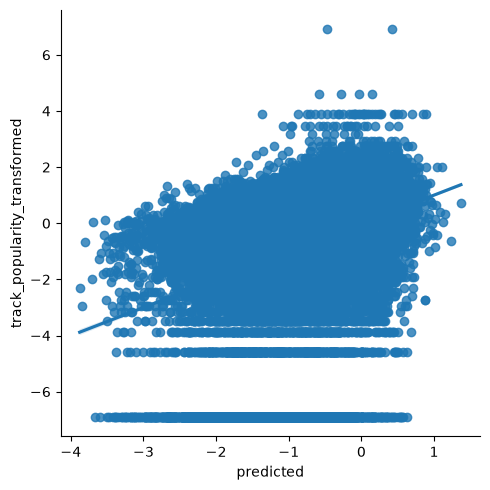

In [55]:
sns.lmplot(data = model_2a4_preds_df, x = 'predicted', y = 'track_popularity_transformed')
plt.show()

<span style="color:#17A697">

### Model 2A.5 — Inputs of your choice with linear main effects and pair-wise interaction

</span>

<span style="color:#17A697">

Q1: How many coefficients were estimated?

</span>

In [39]:
len(model_2a5.params)

11

<span style="color:#E2725B">

11 coefficients.

</span>

<span style="color:#17A697">

Q2: WHICH coefficients (and thus features) are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

</span>

<span style="color:#E2725B">

These coefficients are statistically significant with a p value of < 0.05:

- Intercept
    - coef -0.8569 (negative) / p value 0.000
- danceability
    - coef 0.1040 (positive) / p value 0.000
- energy
    - coef -0.2272 (negative) / p value 0.000
- danceability:energy
    - coef 0.0260 (positive) / p value 0.000
- valence
    - coef 0.0429 (positive) / p value 0.049
- danceability:valence
    - coef 0.0429 (positive) / p value 0.001
- tempo
    - coef 0.0385 (positive) / p value 0.005
- energy:valence
    - coef 0.0921 (positive) / p value 0.000


</span>

<span style="color:#17A697">

Q3: Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?

</span>

<span style="color:#E2725B">

Of the coefficients that are statistically signifant, these 2 have the highest magnitude coefficient values:

- Intercept
    - coef -0.8569 (negative) / p value 0.000
- danceability
    - coef 0.1040 (positive) / p value 0.000

</span>


<span style="color:#17A697">

Q4: Calculate the r-squared and RMSE of the model on the entire dataset, which you used for training the model (later you will use cross-validation to protect against overfitting).

</span>

In [56]:
model_2a5_formula = 'track_popularity_transformed ~ danceability * energy + danceability * valence + danceability * tempo + energy * valence + energy * tempo + valence * tempo'

model_2a5 = smf.ols(model_2a5_formula, data = std_cont_df).fit()
model_2a5_rsquared = model_2a5.rsquared
print('R squared:', model_2a5_rsquared)

model_2a5_preds = model_2a5.predict(std_cont_df)
model_2a5_rmse = rmse(std_cont_df['track_popularity_transformed'], model_2a5_preds)
print("RMSE:", model_2a4_rmse)

R squared: 0.016397784403718307
RMSE: 2.0798674330915503


<span style="color:#17A697">

Q5: Plot a predicted vs observed figure.

</span>

In [57]:
model_2a5_preds_df = pd.concat([std_cont_df, model_2a5_preds], axis = 1)
model_2a5_preds_df.rename(columns={0: 'predicted'}, inplace=True)
model_2a5_preds_df

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,playlist_genre,playlist_subgenre,track_popularity_transformed,predicted
0,0.642049,1.201614,0.173200,1.367123,0.876177,-0.481362,-0.333898,-0.377953,-0.809230,0.031908,0.042927,-0.518874,pop,dance pop,0.663294,-1.113843
1,0.490412,0.643317,1.557627,0.585766,0.876177,-0.688642,-0.468670,-0.359177,1.081061,0.782522,-0.777198,-1.056268,pop,dance pop,0.708185,-0.927803
2,0.138889,1.284529,-1.211227,1.100090,-1.141322,-0.324422,-0.436799,-0.377849,-0.519562,0.439384,0.116227,-0.822017,pop,dance pop,0.847298,-1.078586
3,0.435271,1.279002,0.450085,0.984309,0.876177,-0.050024,-0.667642,-0.377911,0.089582,-1.001795,0.039953,-0.947750,pop,dance pop,0.405465,-1.305987
4,-0.033426,0.742815,-1.211227,0.685151,0.876177,-0.702460,-0.432701,-0.377953,-0.692585,0.919777,0.115037,-0.614172,pop,dance pop,0.800119,-0.937117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,-1.563583,1.234780,-0.934342,1.641519,0.876177,-0.132936,-0.449547,-0.377953,-0.799509,-1.289173,0.270929,-0.358076,edm,progressive electro house,-0.322773,-1.256822
32829,-0.915679,0.483014,-1.488113,0.755423,0.876177,-0.642251,-0.790531,-0.358910,1.197705,-0.474221,0.266134,2.127922,edm,progressive electro house,-1.386294,-1.040686
32830,-0.867431,0.676483,0.173200,0.609190,-1.141322,-0.582041,-0.306579,-0.377948,-0.260352,-0.319809,0.264201,-0.262193,edm,progressive electro house,-1.815290,-1.070589
32831,-0.198848,1.046839,-0.934342,1.123849,0.876177,0.019069,-0.762256,0.188438,0.990337,-0.868829,0.264908,2.367121,edm,progressive electro house,-1.734601,-1.198146


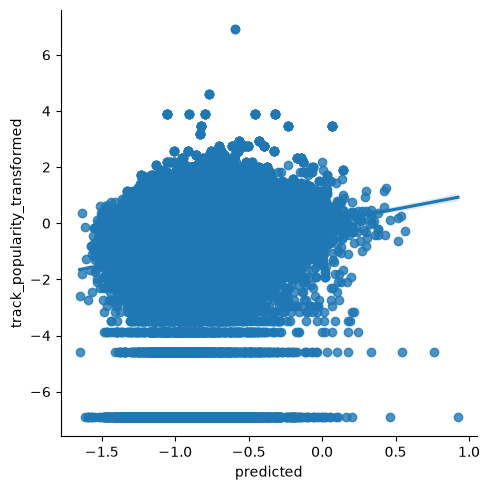

In [58]:
sns.lmplot(data = model_2a5_preds_df, x = 'predicted', y = 'track_popularity_transformed')
plt.show()

<span style="color:#17A697">

### Model 2A.6 — A nonlinear feature transformation on continuous variables of your choice

</span>

<span style="color:#17A697">

LOUDNESS—Q1: How many coefficients were estimated?

</span>

In [74]:
len(model_2a6_loudness.params)

3

<span style="color:#E2725B">

3 coefficients.

</span>

<span style="color:#17A697">

LOUDNESS—Q2: WHICH coefficients (and thus features) are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

</span>

<span style="color:#E2725B">

These coefficients are statistically significant with a p value of < 0.05:

- Intercept
    - coef -0.8222 (negative) / p value 0.000
- loudness
    - coef 0.0545 (positive) / p value 0.000

</span>

<span style="color:#17A697">

LOUDNESS—Q3: Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?

</span>

<span style="color:#E2725B">

Of the coefficients that are statistically signifant, these 2 have the highest magnitude coefficient values:

- Intercept
    - coef -0.8222 (negative) / p value 0.000
- loudness
    - coef 0.0545 (positive) / p value 0.000

</span>


<span style="color:#17A697">

LOUDNESS—Q4: Calculate the r-squared and RMSE of the model on the entire dataset, which you used for training the model (later you will use cross-validation to protect against overfitting).

</span>

In [77]:
model_2a6_loudness_formula = 'track_popularity_transformed ~ loudness + np.power(loudness, 2)'

model_2a6_loudness = smf.ols(model_2a6_loudness_formula, data = std_cont_df).fit()
model_2a6_loudness_rsquared = model_2a6_loudness.rsquared
print('R squared:', model_2a6_loudness_rsquared)

model_2a6_loudness_preds = model_2a6_loudness.predict(std_cont_df)
model_2a6_loudness_rmse = rmse(std_cont_df['track_popularity_transformed'], model_2a6_loudness_preds)
print("RMSE:", model_2a6_loudness_rmse)

R squared: 0.0008033221603347407
RMSE: 2.2114199939318695


<span style="color:#17A697">

LOUDNESS—Q5: Plot a predicted vs observed figure.

</span>

In [81]:
model_2a6_loudness_preds_df = pd.concat([std_cont_df, model_2a6_loudness_preds], axis = 1)
model_2a6_loudness_preds_df.rename(columns={0: 'predicted'}, inplace=True)
model_2a6_loudness_preds_df

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,playlist_genre,playlist_subgenre,track_popularity_transformed,predicted
0,0.642049,1.201614,0.173200,1.367123,0.876177,-0.481362,-0.333898,-0.377953,-0.809230,0.031908,0.042927,-0.518874,pop,dance pop,0.663294,-0.757376
1,0.490412,0.643317,1.557627,0.585766,0.876177,-0.688642,-0.468670,-0.359177,1.081061,0.782522,-0.777198,-1.056268,pop,dance pop,0.708185,-0.792009
2,0.138889,1.284529,-1.211227,1.100090,-1.141322,-0.324422,-0.436799,-0.377849,-0.519562,0.439384,0.116227,-0.822017,pop,dance pop,0.847298,-0.768493
3,0.435271,1.279002,0.450085,0.984309,0.876177,-0.050024,-0.667642,-0.377911,0.089582,-1.001795,0.039953,-0.947750,pop,dance pop,0.405465,-0.773545
4,-0.033426,0.742815,-1.211227,0.685151,0.876177,-0.702460,-0.432701,-0.377953,-0.692585,0.919777,0.115037,-0.614172,pop,dance pop,0.800119,-0.787249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,-1.563583,1.234780,-0.934342,1.641519,0.876177,-0.132936,-0.449547,-0.377953,-0.799509,-1.289173,0.270929,-0.358076,edm,progressive electro house,-0.322773,-0.746730
32829,-0.915679,0.483014,-1.488113,0.755423,0.876177,-0.642251,-0.790531,-0.358910,1.197705,-0.474221,0.266134,2.127922,edm,progressive electro house,-1.386294,-0.783946
32830,-0.867431,0.676483,0.173200,0.609190,-1.141322,-0.582041,-0.306579,-0.377948,-0.260352,-0.319809,0.264201,-0.262193,edm,progressive electro house,-1.815290,-0.790877
32831,-0.198848,1.046839,-0.934342,1.123849,0.876177,0.019069,-0.762256,0.188438,0.990337,-0.868829,0.264908,2.367121,edm,progressive electro house,-1.734601,-0.767474


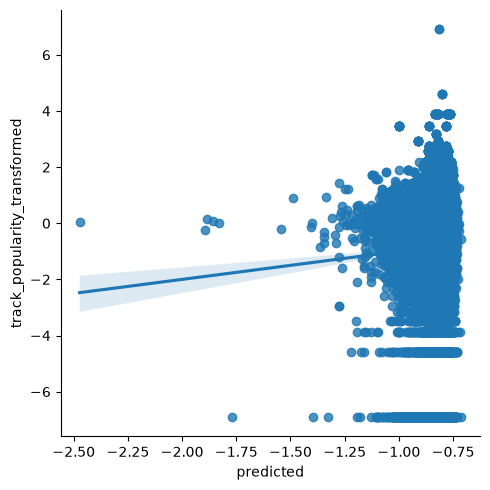

In [82]:
sns.lmplot(data = model_2a6_loudness_preds_df, x = 'predicted', y = 'track_popularity_transformed')
plt.show()

<span style="color:#17A697">

TEMPO—Q1: How many coefficients were estimated?

</span>

In [75]:
len(model_2a6_tempo.params)

3

<span style="color:#E2725B">

3 coefficients.

</span>

<span style="color:#17A697">

TEMPO—Q2: WHICH coefficients (and thus features) are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

</span>

<span style="color:#E2725B">

These coefficients are statistically significant with a p value of < 0.05:

- Intercept
    - coef -0.8930 (negative) / p value 0.000
- tempo
    - coef 0.0494 (positive) / p value 0.000
- np.power(tempo, 2)
    - coef 0.0656 (positive) / p value 0.000

</span>

<span style="color:#17A697">

TEMPO—Q3: Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?

</span>

<span style="color:#E2725B">

Of the coefficients that are statistically signifant, these 2 have the highest magnitude coefficient values:

- Intercept
    - coef -0.8930 (negative) / p value 0.000
- np.power(tempo, 2)
    - coef 0.0656 (positive) / p value 0.000
</span>


<span style="color:#17A697">

TEMPO—Q4: Calculate the r-squared and RMSE of the model on the entire dataset, which you used for training the model (later you will use cross-validation to protect against overfitting).

</span>

In [78]:
model_2a6_tempo_formula = 'track_popularity_transformed ~ tempo + np.power(tempo, 2)'

model_2a6_tempo = smf.ols(model_2a6_tempo_formula, data = std_cont_df).fit()
model_2a6_tempo_rsquared = model_2a6_tempo.rsquared
print('R squared:', model_2a6_tempo_rsquared)

model_2a6_tempo_preds = model_2a6_tempo.predict(std_cont_df)
model_2a6_tempo_rmse = rmse(std_cont_df['track_popularity_transformed'], model_2a6_tempo_preds)
print("RMSE:", model_2a6_tempo_rmse)

R squared: 0.001628547810026304
RMSE: 2.2105066114652936


<span style="color:#17A697">

TEMPO—Q5: Plot a predicted vs observed figure.

</span>

In [83]:
model_2a6_tempo_preds_df = pd.concat([std_cont_df, model_2a6_tempo_preds], axis = 1)
model_2a6_tempo_preds_df.rename(columns={0: 'predicted'}, inplace=True)
model_2a6_tempo_preds_df

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,playlist_genre,playlist_subgenre,track_popularity_transformed,predicted
0,0.642049,1.201614,0.173200,1.367123,0.876177,-0.481362,-0.333898,-0.377953,-0.809230,0.031908,0.042927,-0.518874,pop,dance pop,0.663294,-0.894970
1,0.490412,0.643317,1.557627,0.585766,0.876177,-0.688642,-0.468670,-0.359177,1.081061,0.782522,-0.777198,-1.056268,pop,dance pop,0.708185,-0.814980
2,0.138889,1.284529,-1.211227,1.100090,-1.141322,-0.324422,-0.436799,-0.377849,-0.519562,0.439384,0.116227,-0.822017,pop,dance pop,0.847298,-0.897825
3,0.435271,1.279002,0.450085,0.984309,0.876177,-0.050024,-0.667642,-0.377911,0.089582,-1.001795,0.039953,-0.947750,pop,dance pop,0.405465,-0.894839
4,-0.033426,0.742815,-1.211227,0.685151,0.876177,-0.702460,-0.432701,-0.377953,-0.692585,0.919777,0.115037,-0.614172,pop,dance pop,0.800119,-0.897784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,-1.563583,1.234780,-0.934342,1.641519,0.876177,-0.132936,-0.449547,-0.377953,-0.799509,-1.289173,0.270929,-0.358076,edm,progressive electro house,-0.322773,-0.901537
32829,-0.915679,0.483014,-1.488113,0.755423,0.876177,-0.642251,-0.790531,-0.358910,1.197705,-0.474221,0.266134,2.127922,edm,progressive electro house,-1.386294,-0.901469
32830,-0.867431,0.676483,0.173200,0.609190,-1.141322,-0.582041,-0.306579,-0.377948,-0.260352,-0.319809,0.264201,-0.262193,edm,progressive electro house,-1.815290,-0.901441
32831,-0.198848,1.046839,-0.934342,1.123849,0.876177,0.019069,-0.762256,0.188438,0.990337,-0.868829,0.264908,2.367121,edm,progressive electro house,-1.734601,-0.901451


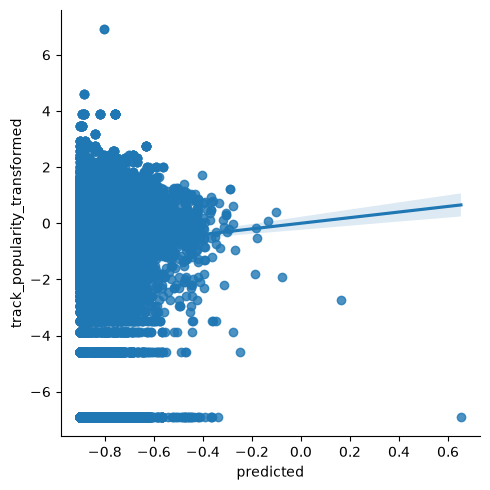

In [84]:
sns.lmplot(data = model_2a6_tempo_preds_df, x = 'predicted', y = 'track_popularity_transformed')
plt.show()

<span style="color:#17A697">

## Part 2C: Best Model Interpretation

</span>

<span style="color:#17A697">

Which model has the best performance on the training set? Describe which features the model used, don't just give a number to refer to the model.

</span>

<span style="color:#E2725B">

Model 2A.4—All inputs (continuous and categorical) with additive features!

This has the best performance on the training set with r-squared being 0.116. This model uses the standardized continuous variables: danceability, energy, key, loudness, mode, speechiness, acousticness, instrumentalness, liveness, valence, tempo, and duration_ms PLUS the categorical variables. Nine of these coefficients are statistically significant (p < 0.05), indicating these features have meaningful relationships with track popularity, though the overall predictive power remains weak.

</span>


<span style="color:#17A697">

Is the best model according to R-squared the SAME as the best model according to RMSE? 

</span>

<span style="color:#E2725B">

Yes, for model 2A.4, we have the highest R-squared and the lowest RMSE. R-squared tells us goodness of fit so we want to focus on the highest value of all the models we've fit. RSME tells us the magnitude of error and we want this to be closer to 0.

R-squared: 0.116147433812689
RMSE: 2.0798674330915503

Comparing all the r-squared and RMSE values, we have a pairing of the highest r-squared and the lowest RMSE.

</span>


<span style="color:#17A697">

Is the best model better than the INTERCEPT-ONLY model? How many coefficients are associated with the BEST model?

</span>

<span style="color:#E2725B">

Yes, model 2A.4 is better than the intercept only model looking at these values below.

Model 2A.1—Intercept only
- R-squared: -2.220446049250313e-16
- RMSE: 2.212308770791808
- 1 coefficient
- 1 statistically significant coefficient

Model 2A.4
- R-squared: 0.116147433812689
- RMSE: 2.0798674330915503
- 41 coefficients
- 9 statistically significant coefficients

</span>


***

<span style="color:#17A697">

# Part 3: Model Predictions

In this section, you will consider multiple formulations (sets of features) for linear regression models and study the coefficients and their confidence intervals to interpret feature importance and quantify relationships to the transformed outcome variable. Before fitting models, if your EDA revealed that continuous variables have vastly different scales, standardize the variables before modeling. Feel free to make additional plots outside of what you completed for the EDA assignment if needed.

### Fit the following 6 models. You may fit additional models if you wish.

**Unlike the EDA assignment, please include all variables except ID variables and categorical variables with too many unique values,** unless the instructions note that you can use variables of your choice.

1. No INPUTS! Fit an INTERCEPT-ONLY or CONSTANT AVERAGE model.

2. Categorical inputs with additive features.

3. Continuous inputs with additive features.

4. All inputs (continuous and categorical) with additive features.

5. Inputs of your choice with linear main effects and pair-wise interactions. Select input variables that you think may be informative for prediction.

6. A nonlinear feature transformation on continuous variables of your choice. You can include any other non-transformed input variables you like if you wish. You can include polynomial transformations and/or sine or log-transformed variables. It's best if these transformations are informed by patterns you see in visualizations, but it's not required. You may include interaction variables if you wish.

### For each model that you fit you must answer the following questions associated with the regression coefficients:

1. How many coefficients were estimated?

2. WHICH coefficients (and thus features) are STATISTICALLY SIGNIFICANT and are the coefficients POSITIVE or NEGATIVE for those features?

3. Which two STATISTICALLY SIGNIFICANT coefficients (and thus features) have the highest MAGNITUDE coefficient values?

4. Calculate the r-squared and RMSE of the model on the entire dataset, which you used for training the model (later you will use cross-validation to protect against overfitting).

5. Plot a predicted vs observed figure.

### Best model interpretation
Answer the following questions to summarize your model fitting exploration:

1. Which model has the best performance on the training set? Describe which features the model used, don't just give a number to refer to the model.

2. Is the best model according to R-squared the SAME as the best model according to RMSE? 

3. Is the best model better than the INTERCEPT-ONLY model? How many coefficients are associated with the BEST model?

</span>

***

<span style="color:#17A697">

# Part 4: Model Generalization Performance with Cross-validation

You have assessed how well your models fit the data they used for training, but now it's time to estimate how well they perform on unseen data. You will use cross-validation to calculate a more reliable estimate of the model performance.

### Choose 3 models to compare: 

1. The model that performed best on the training set

2. A simple model (few features) of your choice

3. A model of medium to high complexity of your choice

Use cross-validation to evaluate the performance of each of the 3 models. You can choose the number of folds and performance metric to focus on.

If you are standardizing variables, make sure to estimate the standardization parameters only for the training folds and not on the test fold as well during cross-validation. Scikit-learn's Pipeline module may be helpful to handle this case.

Visualize the CROSS-VALIDATION results by showing the AVERAGE CROSS-VALIDATION performance metric with the 68% confidence interval for each model.

### Answer the following questions:

1. Which model is the BEST according to CROSS-VALIDATION?

2. How many regression coefficients are associated with the best model?

3. Is this model DIFFERENT from the model identified as the BEST according to the training set? Discuss.

</span>

***

## Formatting Styles


<span style="color:#17A697">

### Section

Lorem ipsum dolor sit amet, consectetur adipiscing.

</span>



<span style="color:#E2725B">

#### Subsection

Lorem ipsum dolor sit amet, consectetur adipiscing.

</span>
